In [2]:
import os
import math
import numpy as np
import pandas as pd
from sklearn import model_selection


# Leaf and Node Class

In [3]:
class Leaf:
    def __init__(self, value):
        self.value = value

    def predict(self, row):
        return self.value


class Node:
    def __init__(self, level, split_feature, split_value, left_node=None, right_node=None):
        self.level = level
        self.split_feature = split_feature
        self.split_value = split_value
        self.left_node = left_node
        self.right_node = right_node

    def predict(self, row):
        if row[self.split_feature] >= self.split_value:
            return self.right_node.predict(row)
        return self.left_node.predict(row)

# Gini Decision Tree Classifier

In [7]:
import math

class GiniDecisionTreeClassifier:

    def __init__(self, max_depth):
        self.max_depth = max_depth
        self.root = None

    def set_root(self, node):
        if self.root is None:
            self.root = node

    def class_counts(self, y):
        values, counts = np.unique(y, return_counts=True)
        return values, counts

    def calc_popular_class(self, y):
        values, counts = self.class_counts(y)
        return values[np.argmax(counts)]

    def calc_gini(self, y):
        values, counts = self.class_counts(y)
        class_probabilities = counts / float(len(y))
        return 1 - np.sum(class_probabilities**2)

    def features_to_check(self, num_features):
        num_features_to_check = int(math.sqrt(num_features))
        return np.random.randint(0, num_features, size=num_features_to_check)

    def data_split(self, X, y, split_feature, split_value):

        idx_right = X[:, split_feature] >= split_value
        right_X = X[idx_right]
        right_y = y[idx_right]

        idx_left = X[:, split_feature] < split_value
        left_X = X[idx_left]
        left_y = y[idx_left]

        return right_X, right_y, left_X, left_y

    def get_best_split(self, X, y):

        num_features = X.shape[1]
        num_rows = len(y)

        best_split_feature = 0
        best_split_value = 0
        best_gini = 1

        for feature in self.features_to_check(num_features - 1):

            values = np.unique(X[:, feature])

            for val in values:

                right_X, right_y, left_X, left_y = self.data_split(X, y, feature, val)

                if len(right_y) == 0 or len(left_y) == 0:
                    continue

                p = float(len(right_X)) / num_rows

                average_gini = (
                    p * self.calc_gini(right_y) +
                    (1 - p) * self.calc_gini(left_y)
                )

                if average_gini < best_gini:
                    best_gini = average_gini
                    best_split_feature = feature
                    best_split_value = val

        return best_split_feature, best_split_value, best_gini

    def fit(self, X, y):
        self.set_root(self.split_node(X, y))

    def split_node(self, X, y, node_level=0):

        node_level += 1

        if len(y) == 1:
            return Leaf(y[0])

        split_feature, split_value, gini = self.get_best_split(X, y)

        if gini == 0.0 or node_level >= self.max_depth:
            return Leaf(self.calc_popular_class(y))

        right_X, right_y, left_X, left_y = self.data_split(X, y, split_feature, split_value)

        if len(right_y) == 0 or len(left_y) == 0:
            return Leaf(self.calc_popular_class(y))

        right_node = self.split_node(right_X, right_y, node_level)
        left_node = self.split_node(left_X, left_y, node_level)

        return Node(node_level, split_feature, split_value, left_node, right_node)

    def predict_labels(self, X_test):

        y_probs = []

        for row in X_test:
            y_probs.append(self.root.predict(row))

        return np.asarray(y_probs)

    def get_accuracy(self, y, y_probs):

        correct = y == y_probs
        return (np.sum(correct) / float(len(y))) * 100.0

# Random Forest

In [8]:
class RandomForest:

    def __init__(self):
        self.forest = []

    def create_subsample(self, X, y, a=0.25):
        """
        return sub sample of size 'n' of the dataset.
        n = a*n
        """
        n = len(y)
        n_tag = int(a * n)

        idx = np.random.randint(0, n, size=n_tag)

        X_subsample = X[idx]
        y_subsample = y[idx]

        return X_subsample, y_subsample

    def fit(self, X, y, T=300, max_depth=4):
        """
        build the forest.
        T : number of trees in the forest. The default is 300.
        """

        for i in range(0, T):
            X_subsample, y_subsample = self.create_subsample(X, y)

            tree = GiniDecisionTreeClassifier(max_depth)

            tree.fit(X_subsample, y_subsample)

            self.forest.append(tree)

    def calc_popular_class(self, y):
        values, counts = np.unique(y, return_counts=True)

        idx = np.argmax(counts)

        popular_class = values[idx]

        return popular_class

    def bagging_predict(self, X_test):
        predictions = []

        for row in X_test:

            all_trees_preds = np.asarray(
                [tree.root.predict(row) for tree in self.forest]
            )

            predictions.append(self.calc_popular_class(all_trees_preds))

        return np.asarray(predictions)

    def get_accuracy(self, y, y_probs):
        correct = y == y_probs
        acc = (np.sum(correct) / float(len(y))) * 100.0
        return acc

# Train the model

In [9]:
DATA_PATH = './wdbc.data'

breast_cancer_data = pd.read_csv(DATA_PATH, header=None)

X = np.asarray(breast_cancer_data.iloc[:, 2:])
y = np.asarray(breast_cancer_data.iloc[:, 1]).astype('str')


# Split to train and test:
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)


# Train the model:
forest = RandomForest()

forest.fit(X_train, y_train)

preds = forest.bagging_predict(X_test)

acc = forest.get_accuracy(y_test, preds)

print("accuracy is:", round(acc, 2))

accuracy is: 96.5


# Predict on Test Data

In [10]:
# Predict on test data
preds = forest.bagging_predict(X_test)

print("First 10 predictions:", preds[:10])
print("First 10 actual labels:", y_test[:10])

First 10 predictions: ['B' 'M' 'M' 'B' 'B' 'M' 'M' 'M' 'M' 'B']
First 10 actual labels: ['B' 'M' 'M' 'B' 'B' 'M' 'M' 'M' 'B' 'B']


# Calculate Accuracy

In [11]:
acc = forest.get_accuracy(y_test, preds)

print("Model Accuracy:", round(acc, 2), "%")

Model Accuracy: 96.5 %


# Confusion Matrix + Accuracy Plot

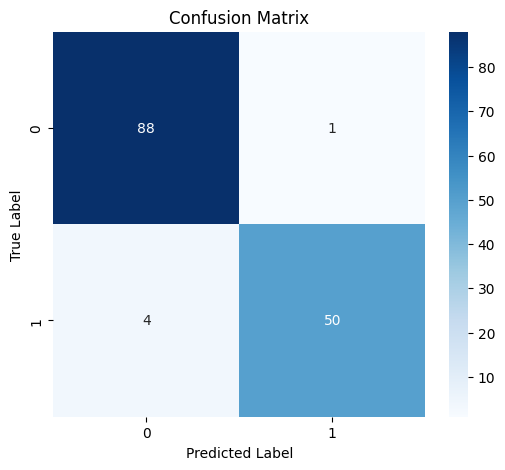

In [13]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

# Accuracy Bar Chart

In [15]:
from sklearn.metrics import classification_report

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           B       0.96      0.99      0.97        89
           M       0.98      0.93      0.95        54

    accuracy                           0.97       143
   macro avg       0.97      0.96      0.96       143
weighted avg       0.97      0.97      0.96       143

